In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving archive (8).zip to archive (8) (1).zip


In [ ]:
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


First 5 Rows:
   Car_Name  Year  Selling_Price  Present_Price  Kms_Driven  Fuel_Type  \
0        90  2014           3.35           5.59       27000          2   
1        93  2013           4.75           9.54       43000          1   
2        68  2017           7.25           9.85        6900          2   
3        96  2011           2.85           4.15        5200          2   
4        92  2014           4.60           6.87       42450          1   

   Seller_Type  Transmission  Owner  
0            0             1      0  
1            0             1      0  
2            0             1      0  
3            0             1      0  
4            0             1      0  

Dataset Shape:
(301, 9)

Columns:
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Colu

In [ ]:
df = df.dropna()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
target_column = input("Enter Target Column Name: ")

X = df.drop(target_column, axis=1)
y = df[target_column]

Enter Target Column Name: Selling_Price


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

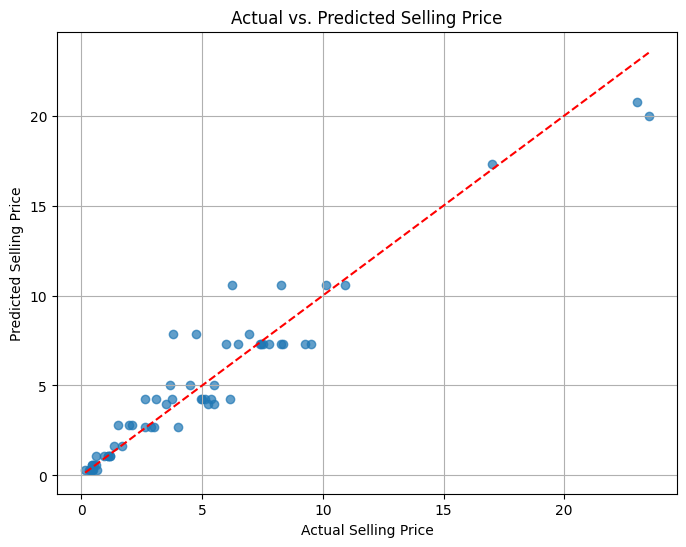

R-squared: 0.9251


In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Actual vs. Predicted Selling Price')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.grid(True)
plt.show()

print(f'R-squared: {r2:.4f}')


Feature Importance:
         Feature  Importance
2  Present_Price    0.926894
1           Year    0.055143
3     Kms_Driven    0.017963
0       Car_Name    0.000000
4      Fuel_Type    0.000000
5    Seller_Type    0.000000
6   Transmission    0.000000
7          Owner    0.000000


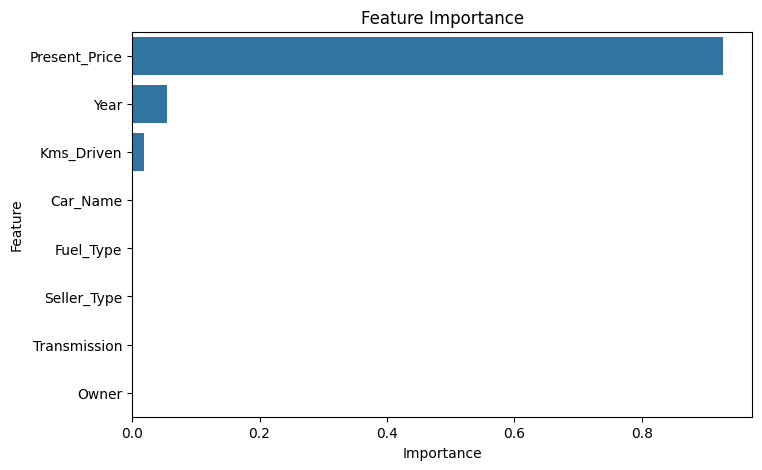

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title("Feature Importance")
plt.show()

** SUPPORT VECTOR MACHINE**

In [ ]:
import os
import zipfile
import numpy as np
import cv2

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from google.colab import files
import zipfile
import os

print("Please upload the ZIP file (e.g., archive (10).zip or similar).")
uploaded = files.upload()

if not uploaded:
    raise ValueError("No file uploaded. Please upload a ZIP file.")

zip_file_name = list(uploaded.keys())[0]
zip_path = f"/content/{zip_file_name}"

# Ensure the data directory exists
data_extract_path = "/content/data"
os.makedirs(data_extract_path, exist_ok=True)

print(f"Extracting '{zip_file_name}' to '{data_extract_path}'...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(data_extract_path)

print("Extraction complete.")

dataset_path = f"{data_extract_path}/ColorClassification" # Assuming 'ColorClassification' is inside the zip
print(f"Dataset path set to: {dataset_path}")

Please upload the ZIP file (e.g., archive (10).zip or similar).


Saving archive (10).zip to archive (10).zip
Extracting 'archive (10).zip' to '/content/data'...
Extraction complete.
Dataset path set to: /content/data/ColorClassification


In [ ]:
X = []
y = []

IMG_SIZE = 64

for label in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, label)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):

            img_path = os.path.join(class_path, img_name)

            try:
                img = cv2.imread(img_path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                # Flatten image
                img = img.flatten()

                X.append(img)
                y.append(label)

            except:
                pass

X = np.array(X)
y = np.array(y)

print("Total Images:", len(X))
print("Classes:", np.unique(y))


Total Images: 425
Classes: ['Black' 'Blue' 'Brown' 'Green' 'Violet' 'White' 'mask_black' 'mask_blue'
 'mask_brown' 'mask_green' 'mask_orange' 'mask_red' 'mask_test'
 'mask_violet' 'mask_white' 'mask_yellow' 'orange' 'red' 'testimg'
 'yellow']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)


SVC(kernel='linear')

In [ ]:
y_pred = svm_model.predict(X_test)


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.1411764705882353

Classification Report:
              precision    recall  f1-score   support

       Black       0.20      0.50      0.29         2
        Blue       0.00      0.00      0.00         2
       Brown       0.20      0.25      0.22         4
       Green       0.00      0.00      0.00         1
      Violet       0.25      0.25      0.25         4
       White       0.33      0.25      0.29         4
  mask_black       0.00      0.00      0.00         2
   mask_blue       0.00      0.00      0.00         2
  mask_brown       0.50      0.50      0.50         4
  mask_green       0.00      0.00      0.00         2
 mask_orange       0.00      0.00      0.00         2
    mask_red       0.20      0.50      0.29         2
   mask_test       0.04      0.05      0.05        19
 mask_violet       0.00      0.00      0.00         4
  mask_white       0.00      0.00      0.00         3
 mask_yellow       0.00      0.00      0.00         2
      orange       1.00     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
svm_model = SVC(kernel='rbf', C=10, gamma='scale')